In [674]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll, make_moons

In [ ]:
# import ot # this was for 2D Wasserstein distance, but decided to not use this since results were not consistent

In [675]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Load Dataset

In [676]:
def get_swiss_roll(n_samples=5000):
    # Generate 3D swiss roll, but we only extract 2 dimensions to make it a 2D spiral
    data, _ = make_swiss_roll(n_samples=n_samples, noise=0.2)
    data = data[:, [0, 2]]
    # Standardize data to have zero mean and reasonable variance
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

In [ ]:
def get_two_moons(n_samples=5000):
    data, _ = make_moons(n_samples=n_samples, noise=0.05)
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)

    # data = data*0.001;
    return torch.tensor(data, dtype=torch.float32)

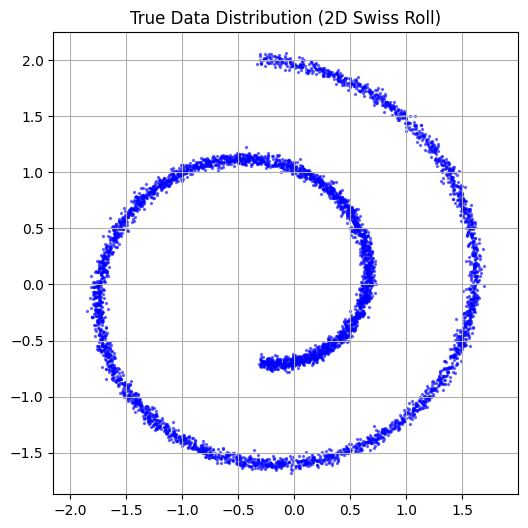

In [677]:
dataset = get_swiss_roll(5000)
# dataset = get_two_moons(5000)


plt.figure(figsize=(6, 6))
plt.scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
plt.title("True Data Distribution (2D Swiss Roll)")
plt.axis('equal')
plt.grid(True)
plt.show()

### Define the Score Network

In [678]:
class ScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        # Input is 3-dimensional: 2D coordinate + 1D scalar sigma
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Softplus(), # Softplus ensures smooth second derivatives for score matching
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 2) # Output is a 2D vector (the score)
        )
        
    def forward(self, x, sigma):
        # x shape: [batch_size, 2]
        # sigma shape: [batch_size, 1]
        inputs = torch.cat([x, sigma], dim=-1)
        return self.net(inputs)

## Baseline experiments

We use the baseline defined in the paper with 10 noise levels and 100 langevin steps

### L = noise Levels

In [713]:
L = 10                 # Number of noise scales
sigma_1 = 1.0           # High noise (blankets the empty canvas space)
sigma_L = 0.01          # Low noise (resolves fine structure)

In [714]:
# Calculate geometric progression base gamma
def make_schedule(sigma_1, sigma_L, L):
    gamma = (sigma_L / sigma_1) ** (1.0 / (L - 1))
    return torch.tensor([sigma_1 * (gamma ** i) for i in range(L)], dtype=torch.float32)

In [715]:
sigmas = make_schedule(sigma_1, sigma_L, L)

In [682]:
print("Noise Schedule (sigmas):")
for idx, s in enumerate(sigmas):
    print(f"Level {idx+1}: {s.item():.4f}")

Noise Schedule (sigmas):
Level 1: 1.0000
Level 2: 0.5995
Level 3: 0.3594
Level 4: 0.2154
Level 5: 0.1292
Level 6: 0.0774
Level 7: 0.0464
Level 8: 0.0278
Level 9: 0.0167
Level 10: 0.0100


### Training loop

We train the noise network for 30000 epochs

At any given noise level $i$, the perturbed data point $x_i$ is drawn from a conditional distribution:$$p(\mathbf{x}_i \mid \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_i \mid \mathbf{x}_0, \sigma_i^2 \mathbf{I})$$

Because the true noise vector points away from the real data, the network's output—the Score Function $\mathbf{s}_\theta(\mathbf{x}_i, \sigma_i)$—learns to approximate the gradient of the log-density:$$\mathbf{s}_\theta(\mathbf{x}_i, \sigma_i) \approx \nabla_{\mathbf{x}_i} \log p(\mathbf{x}_i)$$

In [683]:
def train_network(sigmas):

    network = ScoreNetwork(hidden_dim=128)
    optimizer = optim.Adam(network.parameters(), lr=0.001)
    epochs = 30000 # 30000 gives good results, anything above this will improve the final sample quality, below 30000 generally produces poor quality samples
    batch_size = 128

    for epoch in range(epochs):
    #Sample a clean batch of data
        idx = torch.randint(0, len(dataset), (batch_size,))
        x_clean = dataset[idx]
        
        # Randomly sample an index for the noise schedule per batch item
        noise_idx = torch.randint(0, L, (batch_size,))
        sigma = sigmas[noise_idx].unsqueeze(-1) # Shape: [batch_size, 1]
        
        # Sample pure Gaussian noise
        z = torch.randn_like(x_clean)
        
        # Create the perturbed noisy data
        x_noisy = x_clean + sigma * z
        
        # Compute true analytical score target: -z / sigma
        target_score = -z / sigma
        
        # Forward pass through network
        predicted_score = network(x_noisy, sigma)
        
        # Weighted MSE Loss (scaled by sigma^2 to prevent high noise from drowning out low noise)
        loss = 0.5 * torch.mean(sigma**2 * torch.sum((predicted_score - target_score) ** 2, dim=-1))
        
        # Optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 400 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f}")
    
    return network

In [684]:
network = train_network(sigmas)

Epoch [400/30000] | Loss: 253.7237
Epoch [800/30000] | Loss: 241.6128
Epoch [1200/30000] | Loss: 164.9616
Epoch [1600/30000] | Loss: 239.4515
Epoch [2000/30000] | Loss: 301.1276
Epoch [2400/30000] | Loss: 221.1541
Epoch [2800/30000] | Loss: 229.3335
Epoch [3200/30000] | Loss: 240.0454
Epoch [3600/30000] | Loss: 166.1485
Epoch [4000/30000] | Loss: 174.6272
Epoch [4400/30000] | Loss: 326.6019
Epoch [4800/30000] | Loss: 324.5350
Epoch [5200/30000] | Loss: 155.7071
Epoch [5600/30000] | Loss: 239.6743
Epoch [6000/30000] | Loss: 390.4141
Epoch [6400/30000] | Loss: 158.2235
Epoch [6800/30000] | Loss: 219.6024
Epoch [7200/30000] | Loss: 156.9119
Epoch [7600/30000] | Loss: 208.6056
Epoch [8000/30000] | Loss: 266.5276
Epoch [8400/30000] | Loss: 271.2839
Epoch [8800/30000] | Loss: 193.5247
Epoch [9200/30000] | Loss: 287.9442
Epoch [9600/30000] | Loss: 253.3783
Epoch [10000/30000] | Loss: 194.6620
Epoch [10400/30000] | Loss: 215.6777
Epoch [10800/30000] | Loss: 244.7985
Epoch [11200/30000] | Loss:

### Sample using Annealed Langevin

Start from high noise level, and move towards low noise levels, for eahc noise level, run T steps of Annealed Langevin updates

In [685]:
def sample_annealed_langevin(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    with torch.no_grad():
        # Start from a broad Gaussian distribution matching our highest noise scale
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        # Outer Loop: Walk down through the noise levels from highest to lowest
        for i, sigma in enumerate(sigmas):
            # Compute step size dynamically scaled for this level
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            # Inner Loop: Run Langevin Dynamics for T steps at this noise level
            for t in range(T):
                # 1. Get the score vector field from our network
                score = network(x, sigma_tensor)
                
                # 2. Add fresh noise for the random shake
                z = torch.randn_like(x)
                
                # 3. Update equation
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
    return x.numpy()

### Generating samples using Annealed Langevin Dynamics

In [686]:
generated_samples = sample_annealed_langevin(network, sigmas, n_samples=3000, T=100)

In [687]:
def plot_samples(dataset, generated_samples, title, plot_true=True):
    # 1. Dynamically set the number of columns based on plot_true
    n_cols = 2 if plot_true else 1
    
    # Adjust the overall figure width depending on the number of plots
    fig_width = 12 if plot_true else 6
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, 6))

    # 2. If n_cols == 1, Matplotlib returns a single Axis object instead of a list/array.
    # To keep our indexing code uniform, we wrap it in a list if it isn't one.
    if n_cols == 1:
        axes = [axes]

    axis_idx = 0

    # 3. Plot True Data (only if requested)
    if plot_true:
        axes[axis_idx].scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
        axes[axis_idx].set_title("True Training Data")
        axes[axis_idx].set_xlim(-2.5, 2.5)
        axes[axis_idx].set_ylim(-2.5, 2.5)
        axes[axis_idx].grid(True)
        axis_idx += 1  # Move to the next plot slot

    # 4. Plot Generated Data
    axes[axis_idx].scatter(generated_samples[:, 0], generated_samples[:, 1], s=2, alpha=0.5, color='#a1112a')
    axes[axis_idx].set_title(title)
    axes[axis_idx].set_xlim(-2.5, 2.5)
    axes[axis_idx].set_ylim(-2.5, 2.5)
    axes[axis_idx].grid(True)

    plt.tight_layout() # Ensures labels don't overlap boundaries nicely
    plt.show()
    

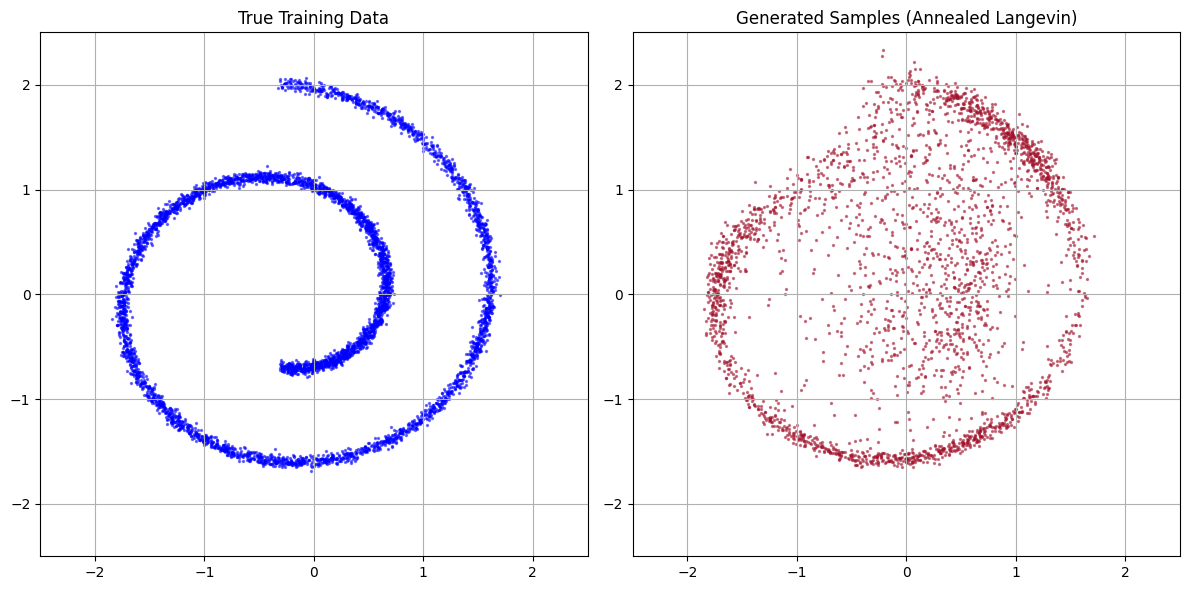

In [688]:
plot_samples(dataset, generated_samples, "Generated Samples (Annealed Langevin)", True)

### Score vector field

In [711]:
def plot_score_field_grid(network, sigmas, dataset, level_idx=4, grid_res=25):
    """
    Plots the score vector field at a specific noise level index.
    - level_idx: choose which index of the sigmas array to visualize
    """
    network.eval()
    sigma_val = sigmas[level_idx].item()
    
    x_range = np.linspace(-2.5, 2.5, grid_res)
    y_range = np.linspace(-2.5, 2.5, grid_res)
    X, Y = np.meshgrid(x_range, y_range)
    
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    sigma_tensor = torch.full((grid_tensor.shape[0], 1), sigma_val)
    
    with torch.no_grad():
        # Shape: [grid_res * grid_res, 2]
        predicted_scores = network(grid_tensor, sigma_tensor).numpy()
        
    # Reshape vectors back into a 2D grid structure for plotting
    U = predicted_scores[:, 0].reshape(X.shape)
    V = predicted_scores[:, 1].reshape(Y.shape)
    
    magnitudes = np.sqrt(U**2 + V**2)
    
    plt.figure(figsize=(6, 6))
    # Underlay a subset of the true data points for reference
    plt.scatter(dataset[:1000, 0], dataset[:1000, 1], s=4, color='blue', alpha=0.3, label='True Manifold')
    
    # angles='xy', scale_units='xy' ensure arrows scale accurately with the axis units
    quiver = plt.quiver(X, Y, U/magnitudes, V/magnitudes, magnitudes, cmap='inferno', 
                        angles='xy', scale_units='xy', scale=10, alpha=0.8)
    
    plt.colorbar(quiver, label='Score Vector Magnitude')
    plt.title(f"Learned Vector Score Field\nNoise Level {level_idx + 1}/{len(sigmas)} ($\\sigma$ = {sigma_val:.4f})")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.xlim(-2.7, 2.7)
    plt.ylim(-2.7, 2.7)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.show()

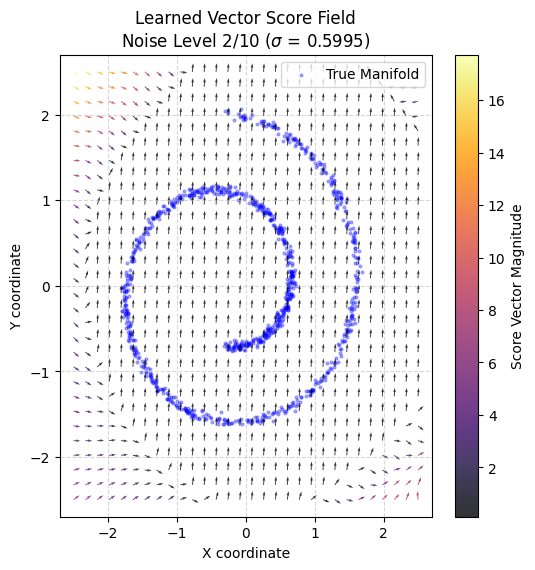

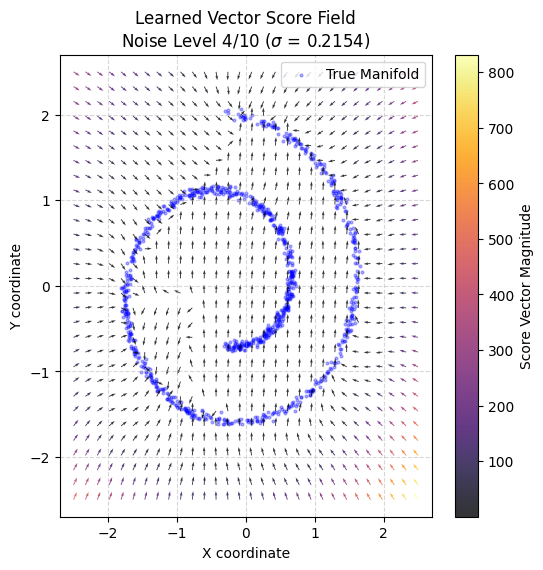

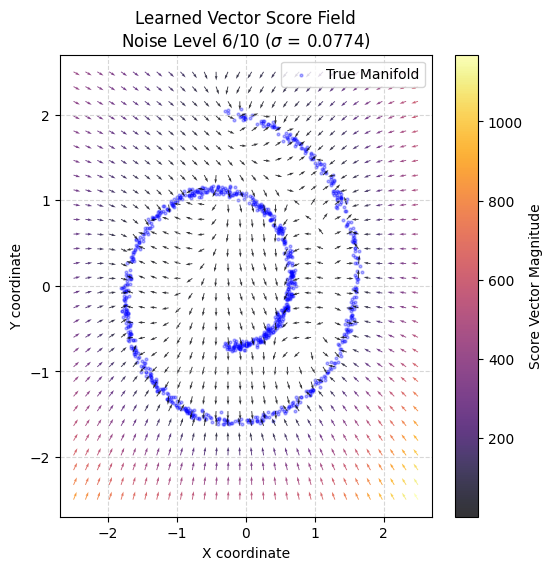

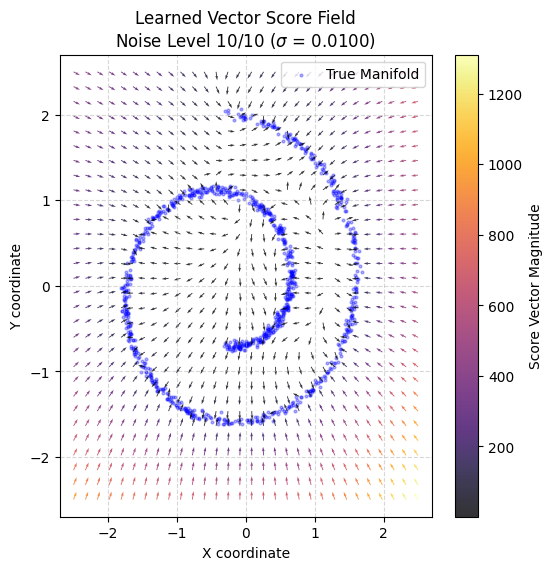

In [712]:
plot_score_field_grid(network, sigmas, dataset, level_idx=1, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=3, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=5, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=9, grid_res=30)
# plot_score_field_grid(network, sigmas, dataset, level_idx=45, grid_res=30)

## Extensions

### varying T, fixed L

We fix L at the baseline, 10 and vary number of Langevin steps

In [689]:
samples_T_2  = sample_annealed_langevin(network, sigmas, n_samples=3000, T=2)
samples_T_50 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=50)
samples_T_100 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=100)
samples_T_200 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=200)

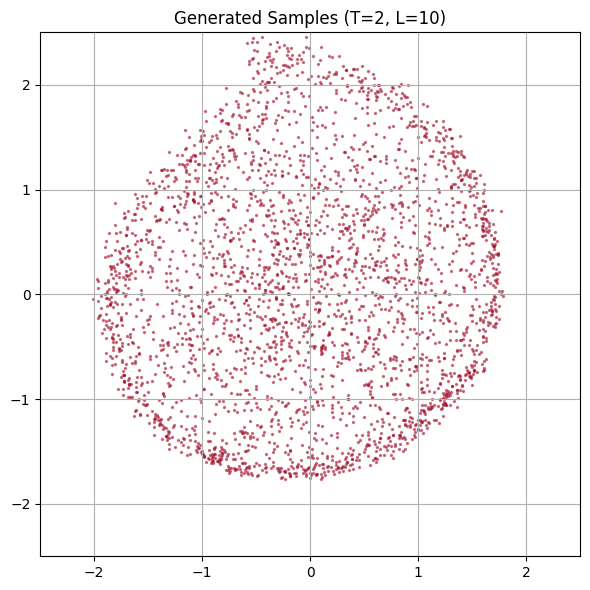

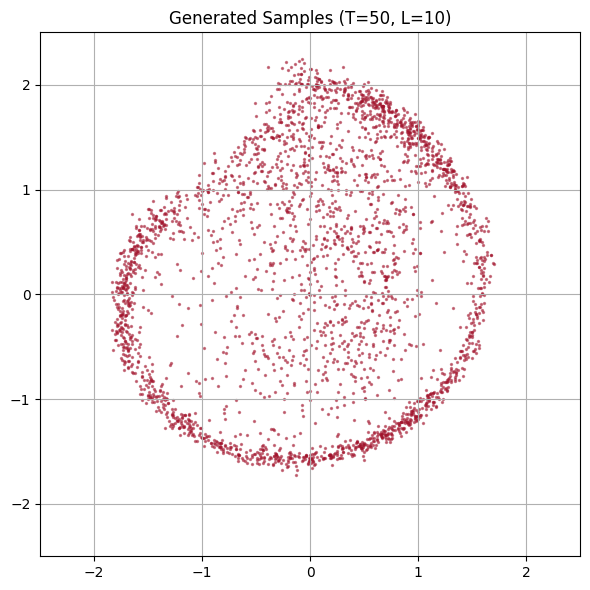

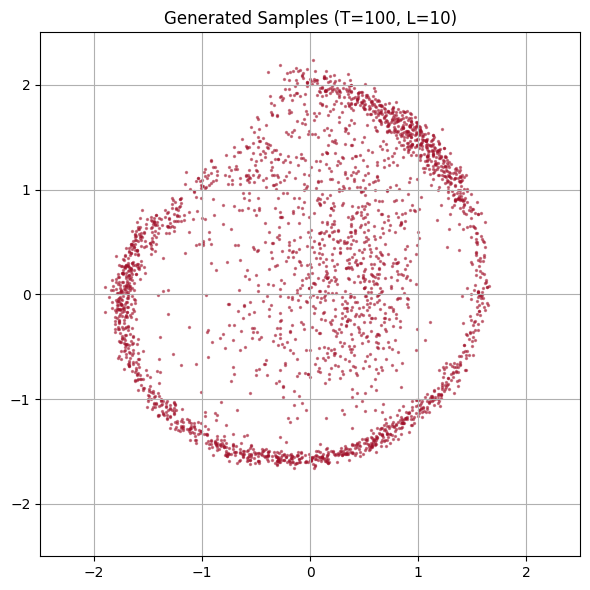

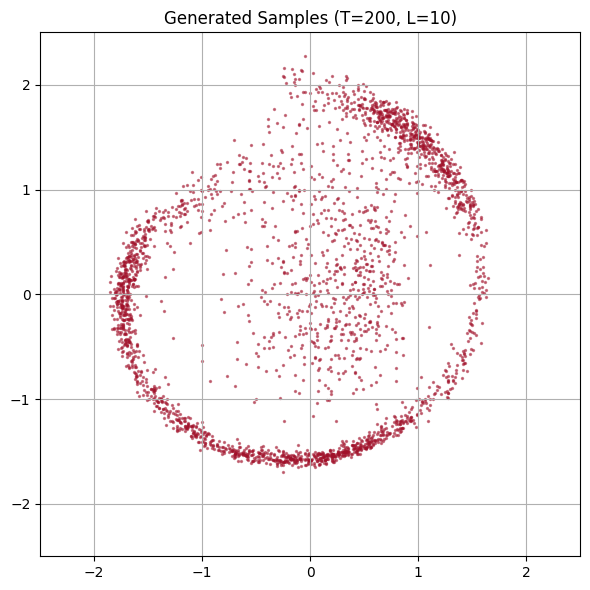

In [690]:
plot_samples(dataset, samples_T_2, "Generated Samples (T=2, L=10)", False)
plot_samples(dataset, samples_T_50, "Generated Samples (T=50, L=10)", False)
plot_samples(dataset, samples_T_100, "Generated Samples (T=100, L=10)", False)
plot_samples(dataset, samples_T_200, "Generated Samples (T=200, L=10)", False)

### varying L fixed T

We fix T at 100 and vary number of noise levels. We do not change the boundaries of noise levels, by increasing L, we make each noise increament finer. We also train a new network for each L, since training depends on L and if we do not retrain, the sampling does not give better results with increasing L

In [691]:
L_SWEEP    = [10, 20, 30, 40, 50]
# L_SWEEP    = [50]
all_samples = {}
SIGMA_1 = 1.0
SIGMA_L = 0.01
networks = {}
BASELINE_EPS = 0.00002
for L in L_SWEEP:
    sched          = make_schedule(SIGMA_1, SIGMA_L, L)
    adjusted_eps = BASELINE_EPS * (10 / L)
    networks[L] = train_network(sched)
    samples        = sample_annealed_langevin(networks[L], sched, 3000, T=100, eps=adjusted_eps)
    all_samples[L] = samples
    valid = int(np.isfinite(samples).all(axis=1).sum())
    # print(f"L={L:<3}  T={100}")

Epoch [400/30000] | Loss: 216.8079
Epoch [800/30000] | Loss: 116.0800
Epoch [1200/30000] | Loss: 474.0186
Epoch [1600/30000] | Loss: 275.0314
Epoch [2000/30000] | Loss: 234.1582
Epoch [2400/30000] | Loss: 271.9010
Epoch [2800/30000] | Loss: 215.7646
Epoch [3200/30000] | Loss: 348.7619
Epoch [3600/30000] | Loss: 286.9209
Epoch [4000/30000] | Loss: 338.0227
Epoch [4400/30000] | Loss: 151.3220
Epoch [4800/30000] | Loss: 269.5305
Epoch [5200/30000] | Loss: 221.5413
Epoch [5600/30000] | Loss: 171.6248
Epoch [6000/30000] | Loss: 153.5894
Epoch [6400/30000] | Loss: 185.2506
Epoch [6800/30000] | Loss: 114.6806
Epoch [7200/30000] | Loss: 221.0138
Epoch [7600/30000] | Loss: 313.2137
Epoch [8000/30000] | Loss: 219.4761
Epoch [8400/30000] | Loss: 265.5328
Epoch [8800/30000] | Loss: 107.6579
Epoch [9200/30000] | Loss: 204.0387
Epoch [9600/30000] | Loss: 109.7517
Epoch [10000/30000] | Loss: 210.5292
Epoch [10400/30000] | Loss: 198.6196
Epoch [10800/30000] | Loss: 330.3906
Epoch [11200/30000] | Loss:

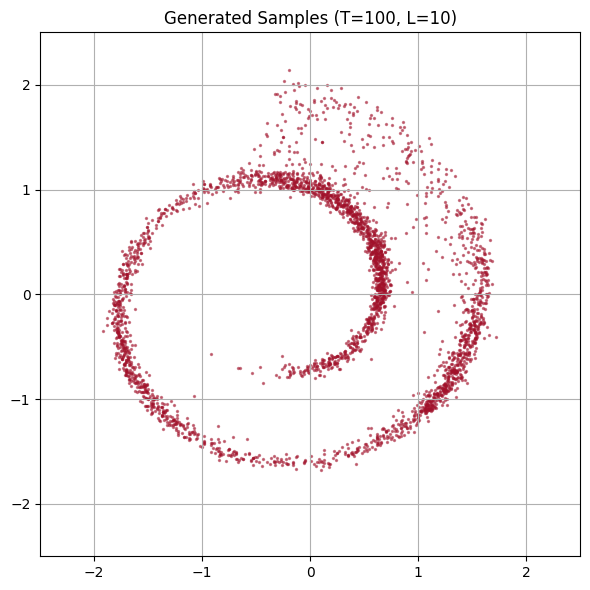

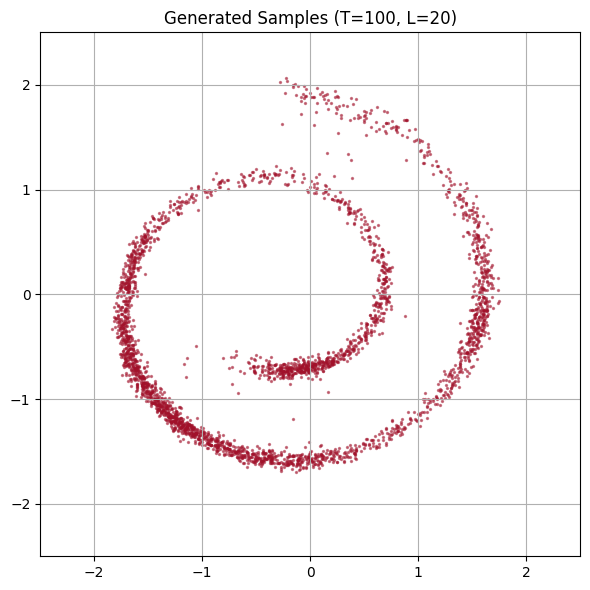

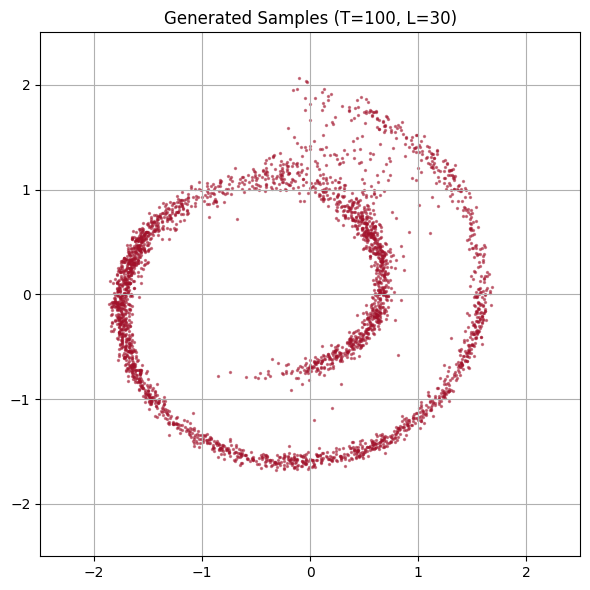

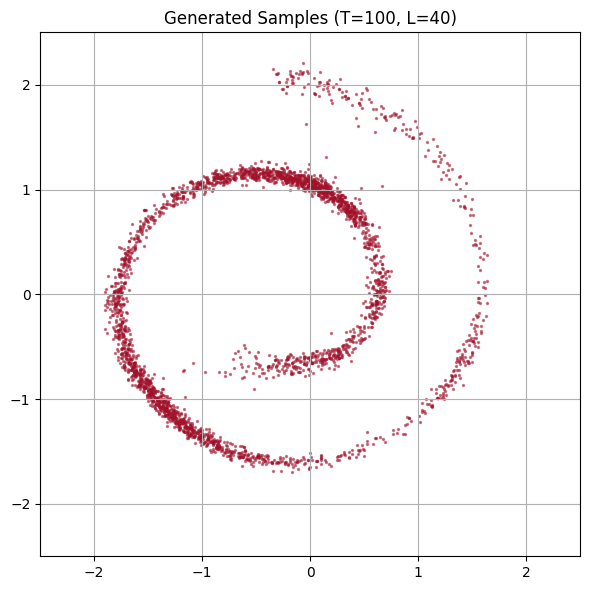

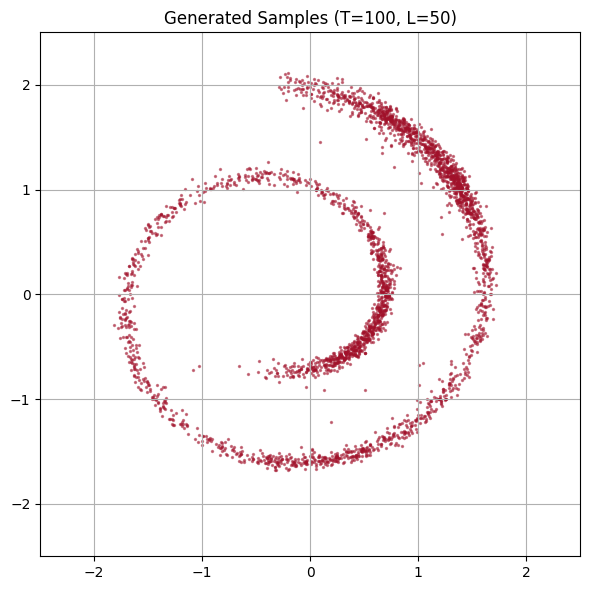

In [692]:
L_SWEEP    = [10, 20, 30, 40, 50]
# L_SWEEP    = [50]
for L in L_SWEEP:
    plot_samples(dataset, all_samples[L], f"Generated Samples (T=100, L={L})", False)

### Comparing generated data with true data

#### T sweep

In [703]:
from sklearn.neighbors import NearestNeighbors

def nn_distance_T(samples, real, n_real=1500):
    """
    Nearest Neighbour Distance for the T sweep.
    For each generated point, find distance to closest real point.
    Lower is better. Rewards tightness to the true manifold.
    """
    mask = np.isfinite(samples).all(axis=1)
    s    = samples[mask]
    if len(s) == 0:
        return float("inf"), 0
    r    = real[:n_real]
    nbrs = NearestNeighbors(n_neighbors=1).fit(r)
    dists, _ = nbrs.kneighbors(s)
    return float(dists.mean()), int(mask.sum())


real_sub_T = dataset.numpy()
results_nnd_T = {}

header = "  T    L    NND Score  Valid"
print(header)
print("-" * len(header))
T_SWEEP = [2, 50, 100, 200]
for T in T_SWEEP:
    sample_dict = {2: samples_T_2, 50: samples_T_50, 100: samples_T_100, 200: samples_T_200}
    nnd, valid = nn_distance_T(sample_dict[T], real_sub_T)
    results_nnd_T[T] = nnd
    print(f"  {T:<4} {10:<4} {nnd:<10.4f} {valid}/3000")

  T    L    NND Score  Valid
----------------------------
  2    10   0.2041     3000/3000
  50   10   0.1163     2865/3000
  100  10   0.1059     2799/3000
  200  10   0.0828     2717/3000


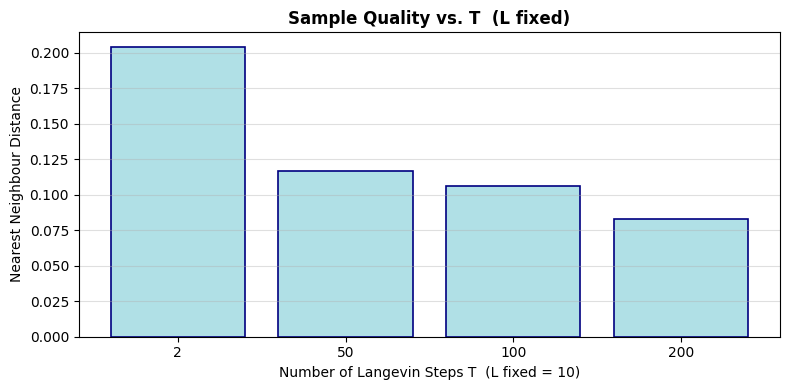

In [704]:
x_pos  = list(range(len(T_SWEEP)))
labels = [str(T) for T in T_SWEEP]
scores = [results_nnd_T[T] for T in T_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="powderblue", edgecolor="navy", linewidth=1.2)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of Langevin Steps T  (L fixed = {10})")
ax.set_ylabel("Nearest Neighbour Distance")
ax.set_title("Sample Quality vs. T  (L fixed)", fontweight="bold")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

#### L sweep

In [705]:
from sklearn.neighbors import NearestNeighbors

def nn_distance_T(samples, real, n_real=1500):
    """
    Nearest Neighbour Distance for the L sweep.
    For each generated point, find distance to closest real point.
    Lower is better. Rewards tightness to the true manifold.
    """
    mask = np.isfinite(samples).all(axis=1)
    s    = samples[mask]
    if len(s) == 0:
        return float("inf"), 0
    r    = real[:n_real]
    nbrs = NearestNeighbors(n_neighbors=1).fit(r)
    dists, _ = nbrs.kneighbors(s)
    return float(dists.mean()), int(mask.sum())


real_sub_L = dataset.numpy()
results_nnd_L = {}

header = "  T    L    NND Score  Valid"
print(header)
print("-" * len(header))
for L in L_SWEEP:
    # sample_dict = {2: samples_T_2, 50: samples_T_50, 100: samples_T_100, 200: samples_T_200}
    nnd, valid = nn_distance_T(all_samples[L], real_sub_L)
    results_nnd_L[L] = nnd
    print(f"  {100:<4} {L:<4} {nnd:<10.4f} {valid}/3000")

  T    L    NND Score  Valid
----------------------------
  100  10   0.0378     3000/3000
  100  20   0.0283     3000/3000
  100  30   0.0345     3000/3000
  100  40   0.0285     3000/3000
  100  50   0.0276     3000/3000


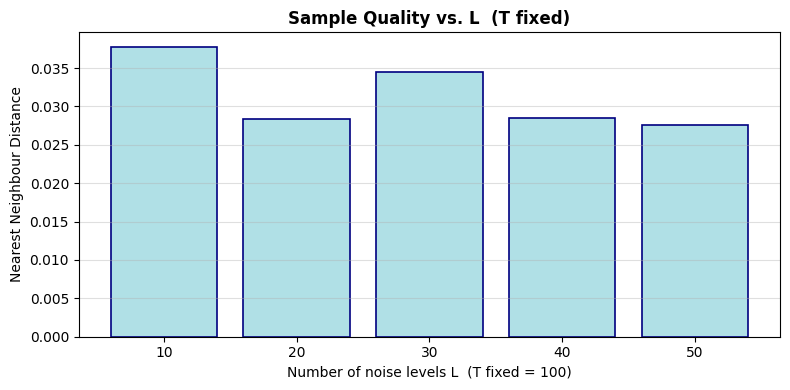

In [706]:
x_pos  = list(range(len(L_SWEEP)))
labels = [str(L) for L in L_SWEEP]
scores = [results_nnd_L[L] for L in L_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="powderblue", edgecolor="navy", linewidth=1.2)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of noise levels L  (T fixed = {100})")
ax.set_ylabel("Nearest Neighbour Distance")
ax.set_title("Sample Quality vs. L  (T fixed)", fontweight="bold")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

### Additional visualizations

#### additional code - fine track evolution for varying L

Epoch [400/30000] | Loss: 257.1748
Epoch [800/30000] | Loss: 230.8869
Epoch [1200/30000] | Loss: 238.1036
Epoch [1600/30000] | Loss: 151.0796
Epoch [2000/30000] | Loss: 199.2108
Epoch [2400/30000] | Loss: 232.3462
Epoch [2800/30000] | Loss: 383.7277
Epoch [3200/30000] | Loss: 241.7971
Epoch [3600/30000] | Loss: 225.7762
Epoch [4000/30000] | Loss: 216.9452
Epoch [4400/30000] | Loss: 235.4986
Epoch [4800/30000] | Loss: 243.7345
Epoch [5200/30000] | Loss: 263.1077
Epoch [5600/30000] | Loss: 381.2868
Epoch [6000/30000] | Loss: 221.6022
Epoch [6400/30000] | Loss: 345.7513
Epoch [6800/30000] | Loss: 277.7912
Epoch [7200/30000] | Loss: 312.4047
Epoch [7600/30000] | Loss: 151.4684
Epoch [8000/30000] | Loss: 119.4942
Epoch [8400/30000] | Loss: 242.0916
Epoch [8800/30000] | Loss: 363.4879
Epoch [9200/30000] | Loss: 414.4996
Epoch [9600/30000] | Loss: 201.2952
Epoch [10000/30000] | Loss: 250.5023
Epoch [10400/30000] | Loss: 293.5566
Epoch [10800/30000] | Loss: 198.5715
Epoch [11200/30000] | Loss:

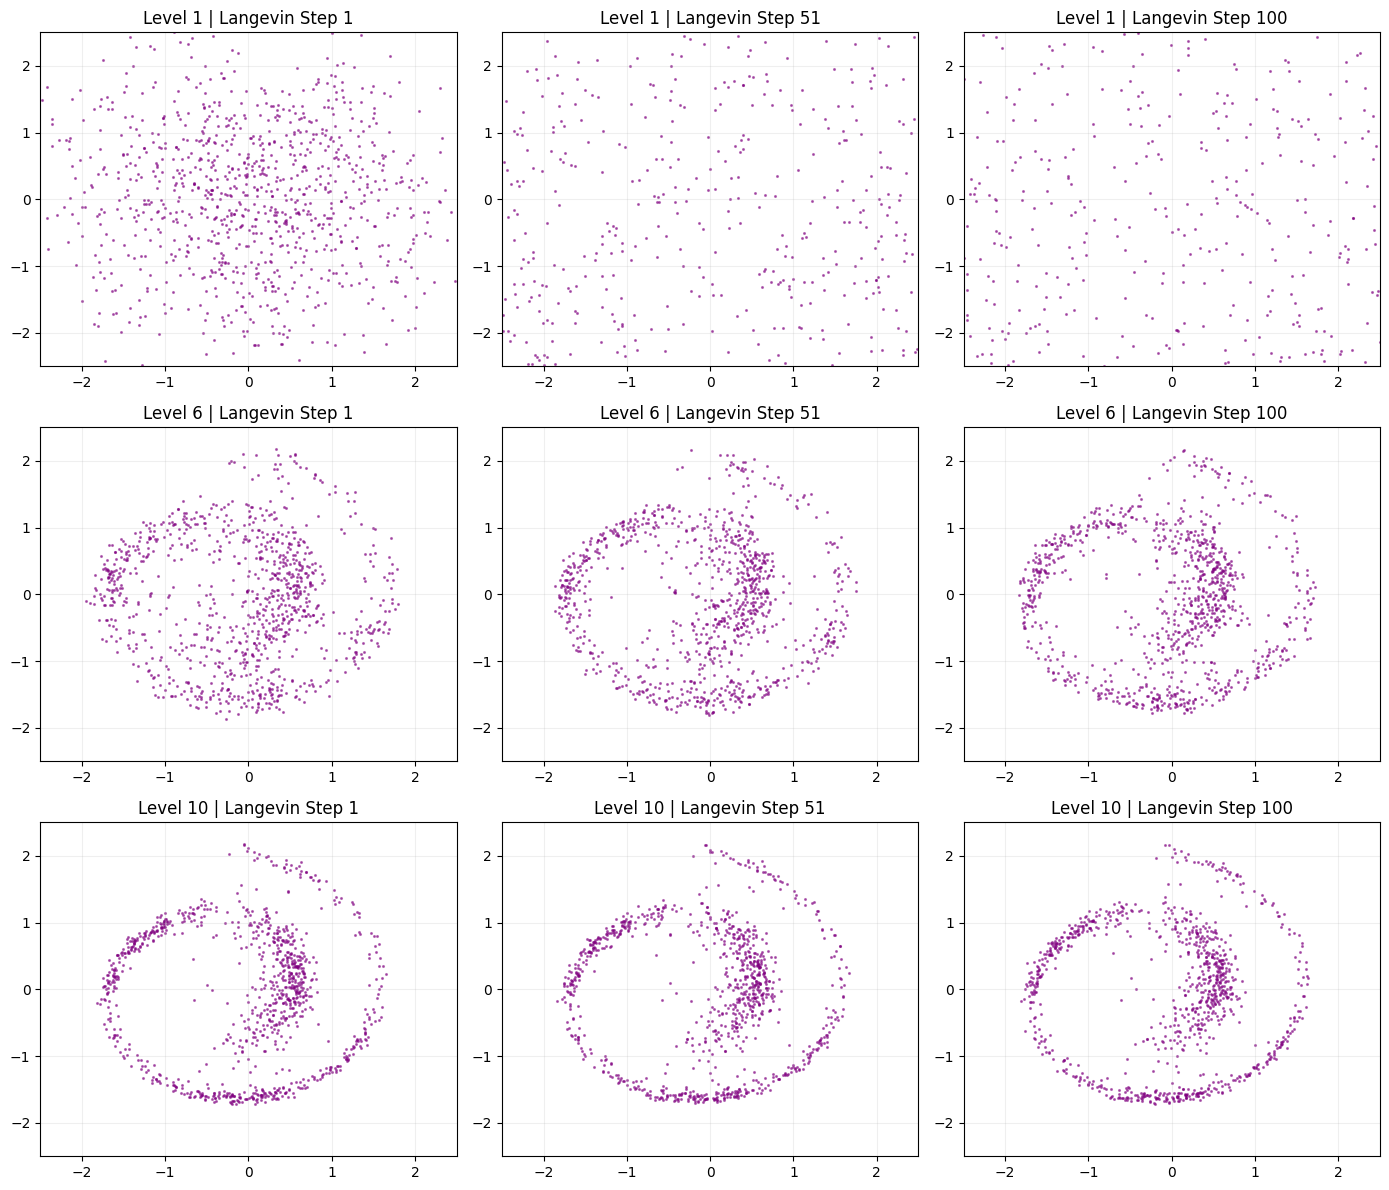

Epoch [400/30000] | Loss: 171.8332
Epoch [800/30000] | Loss: 116.1620
Epoch [1200/30000] | Loss: 172.4402
Epoch [1600/30000] | Loss: 147.1655
Epoch [2000/30000] | Loss: 144.6258
Epoch [2400/30000] | Loss: 151.3713
Epoch [2800/30000] | Loss: 156.5521
Epoch [3200/30000] | Loss: 132.6781
Epoch [3600/30000] | Loss: 188.5349
Epoch [4000/30000] | Loss: 158.3295
Epoch [4400/30000] | Loss: 329.3665
Epoch [4800/30000] | Loss: 137.5106
Epoch [5200/30000] | Loss: 123.9920
Epoch [5600/30000] | Loss: 84.2438
Epoch [6000/30000] | Loss: 139.3887
Epoch [6400/30000] | Loss: 170.1482
Epoch [6800/30000] | Loss: 162.9363
Epoch [7200/30000] | Loss: 186.2672
Epoch [7600/30000] | Loss: 168.7978
Epoch [8000/30000] | Loss: 216.8737
Epoch [8400/30000] | Loss: 133.9665
Epoch [8800/30000] | Loss: 258.7981
Epoch [9200/30000] | Loss: 129.8267
Epoch [9600/30000] | Loss: 156.8800
Epoch [10000/30000] | Loss: 150.0963
Epoch [10400/30000] | Loss: 120.9734
Epoch [10800/30000] | Loss: 243.3978
Epoch [11200/30000] | Loss: 

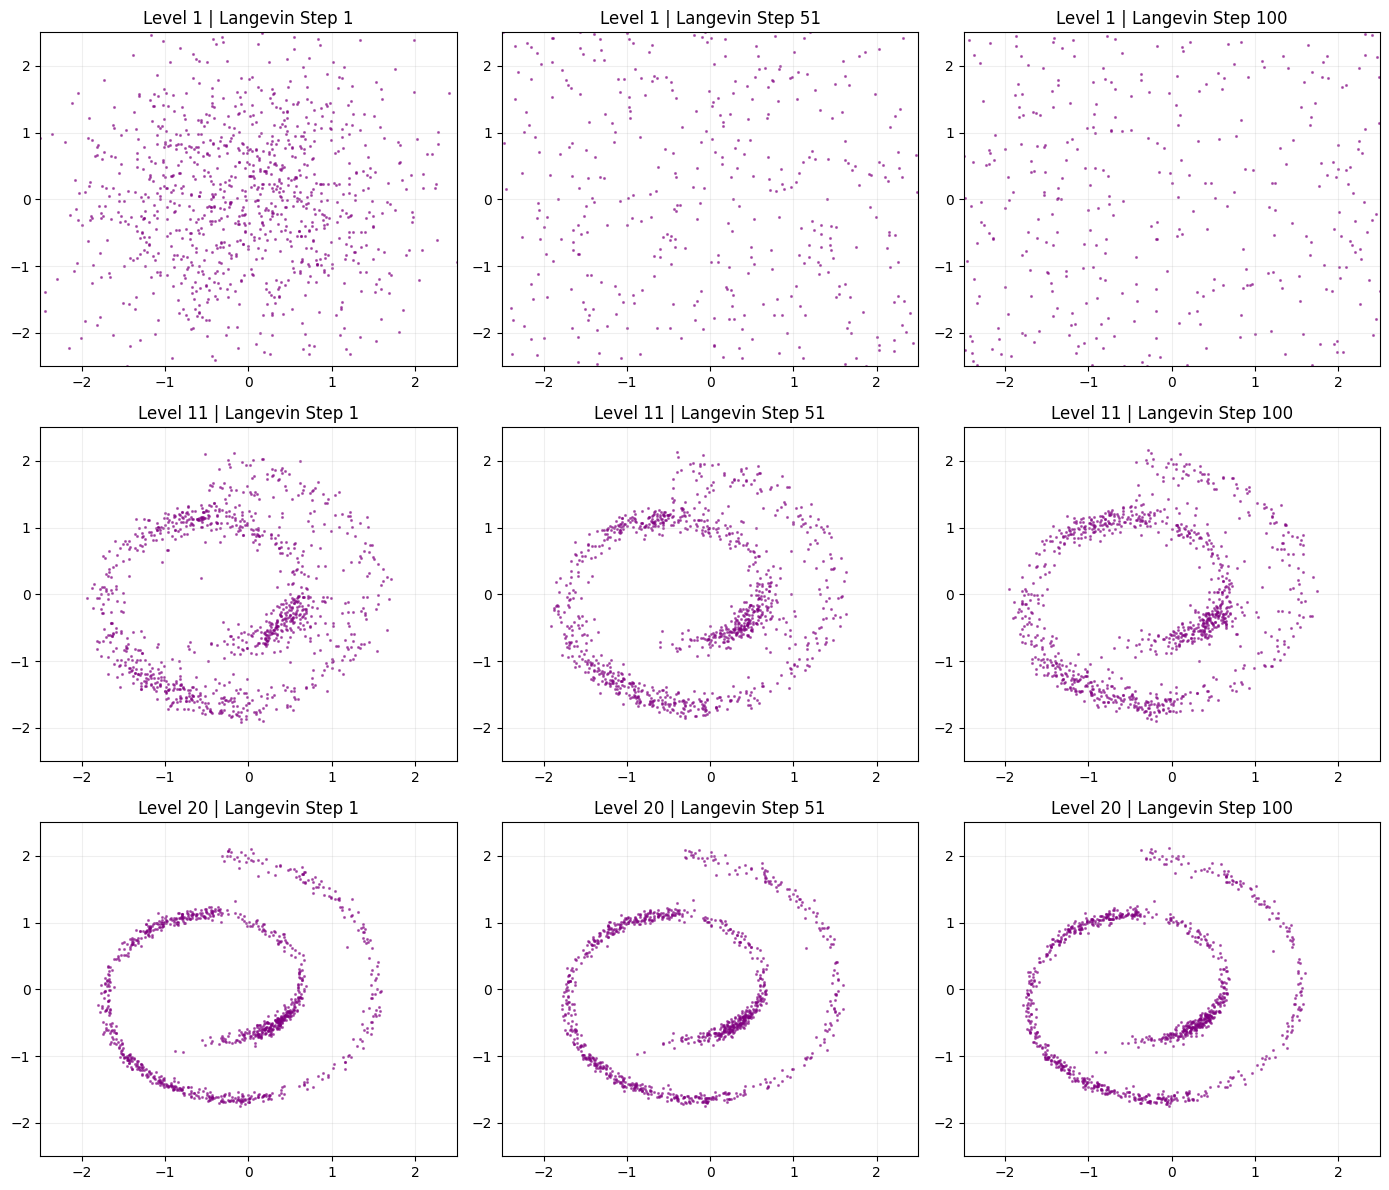

Epoch [400/30000] | Loss: 142.1619
Epoch [800/30000] | Loss: 128.6656
Epoch [1200/30000] | Loss: 147.8818
Epoch [1600/30000] | Loss: 114.4258
Epoch [2000/30000] | Loss: 131.1598
Epoch [2400/30000] | Loss: 233.8923
Epoch [2800/30000] | Loss: 167.5157
Epoch [3200/30000] | Loss: 104.3429
Epoch [3600/30000] | Loss: 130.4349
Epoch [4000/30000] | Loss: 185.4112
Epoch [4400/30000] | Loss: 130.8860
Epoch [4800/30000] | Loss: 171.9320
Epoch [5200/30000] | Loss: 130.4758
Epoch [5600/30000] | Loss: 224.3743
Epoch [6000/30000] | Loss: 130.1500
Epoch [6400/30000] | Loss: 79.5788
Epoch [6800/30000] | Loss: 128.7141
Epoch [7200/30000] | Loss: 111.6964
Epoch [7600/30000] | Loss: 178.3524
Epoch [8000/30000] | Loss: 240.7487
Epoch [8400/30000] | Loss: 73.8428
Epoch [8800/30000] | Loss: 144.6619
Epoch [9200/30000] | Loss: 182.5499
Epoch [9600/30000] | Loss: 112.7438
Epoch [10000/30000] | Loss: 132.1057
Epoch [10400/30000] | Loss: 106.9890
Epoch [10800/30000] | Loss: 137.4324
Epoch [11200/30000] | Loss: 9

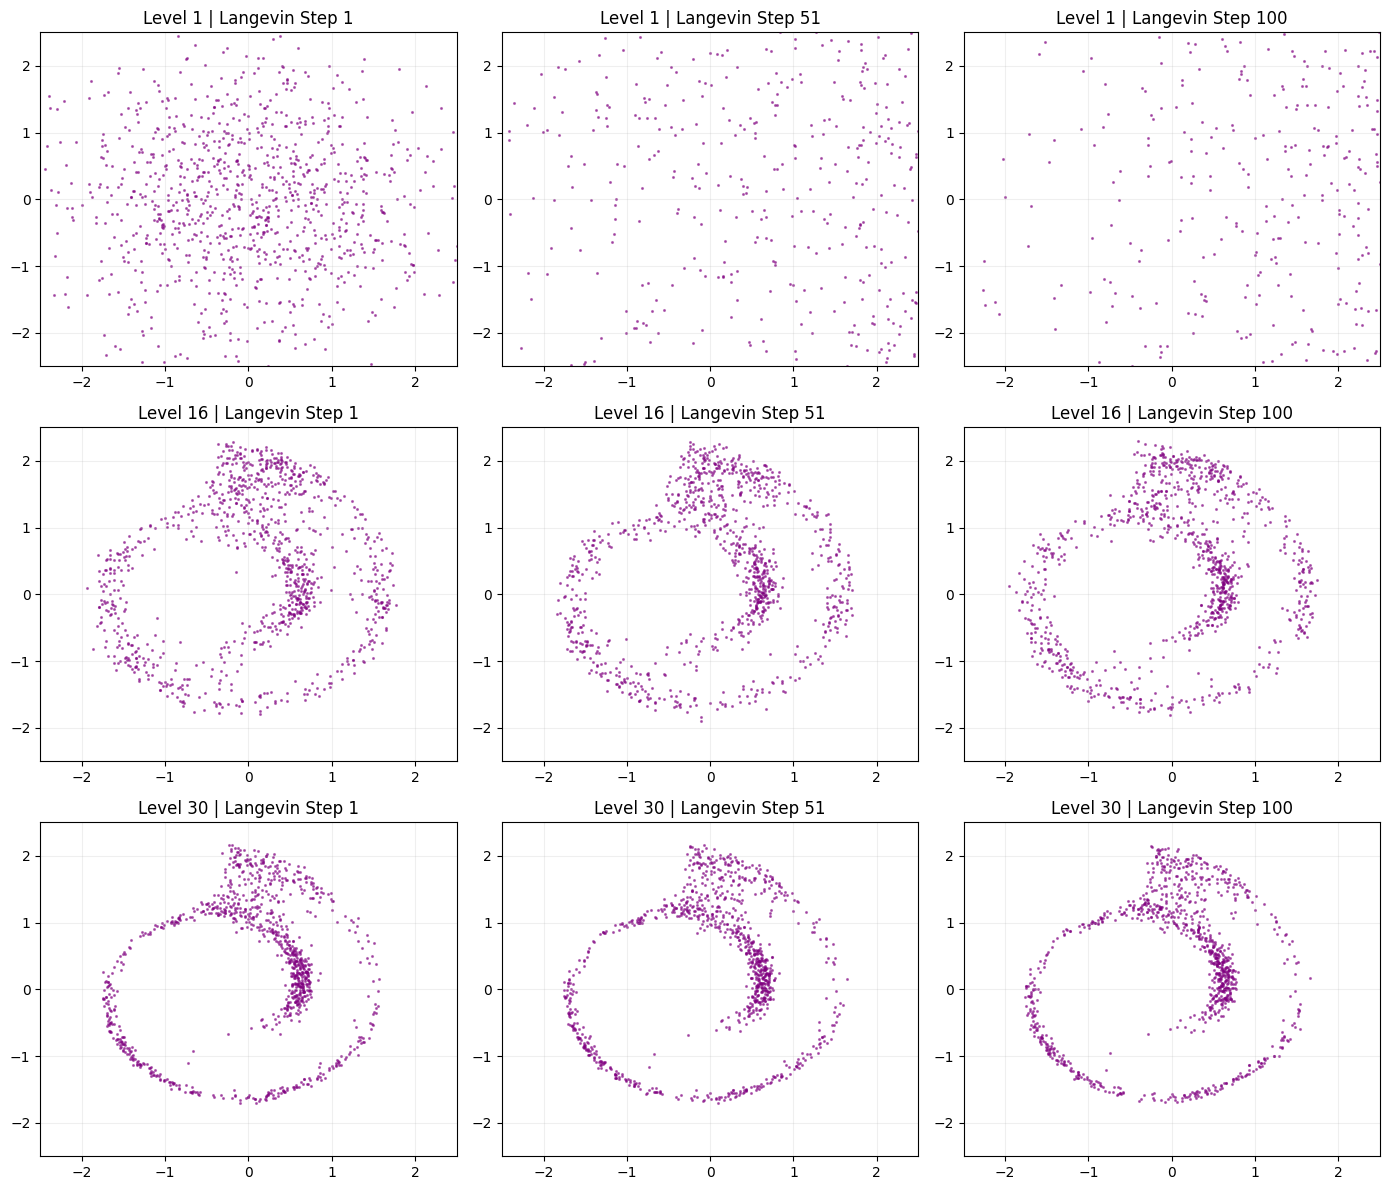

Epoch [400/30000] | Loss: 143.0386
Epoch [800/30000] | Loss: 122.8927
Epoch [1200/30000] | Loss: 189.9501
Epoch [1600/30000] | Loss: 120.1038
Epoch [2000/30000] | Loss: 113.9223
Epoch [2400/30000] | Loss: 93.7596
Epoch [2800/30000] | Loss: 138.3589
Epoch [3200/30000] | Loss: 128.9436
Epoch [3600/30000] | Loss: 167.6040
Epoch [4000/30000] | Loss: 177.0361
Epoch [4400/30000] | Loss: 164.0029
Epoch [4800/30000] | Loss: 122.7832
Epoch [5200/30000] | Loss: 143.8435
Epoch [5600/30000] | Loss: 99.5545
Epoch [6000/30000] | Loss: 144.4598
Epoch [6400/30000] | Loss: 124.4180
Epoch [6800/30000] | Loss: 137.5597
Epoch [7200/30000] | Loss: 149.3068
Epoch [7600/30000] | Loss: 97.2514
Epoch [8000/30000] | Loss: 94.6702
Epoch [8400/30000] | Loss: 121.5399
Epoch [8800/30000] | Loss: 179.0217
Epoch [9200/30000] | Loss: 144.5060
Epoch [9600/30000] | Loss: 111.1254
Epoch [10000/30000] | Loss: 88.3517
Epoch [10400/30000] | Loss: 101.4185
Epoch [10800/30000] | Loss: 174.6369
Epoch [11200/30000] | Loss: 97.0

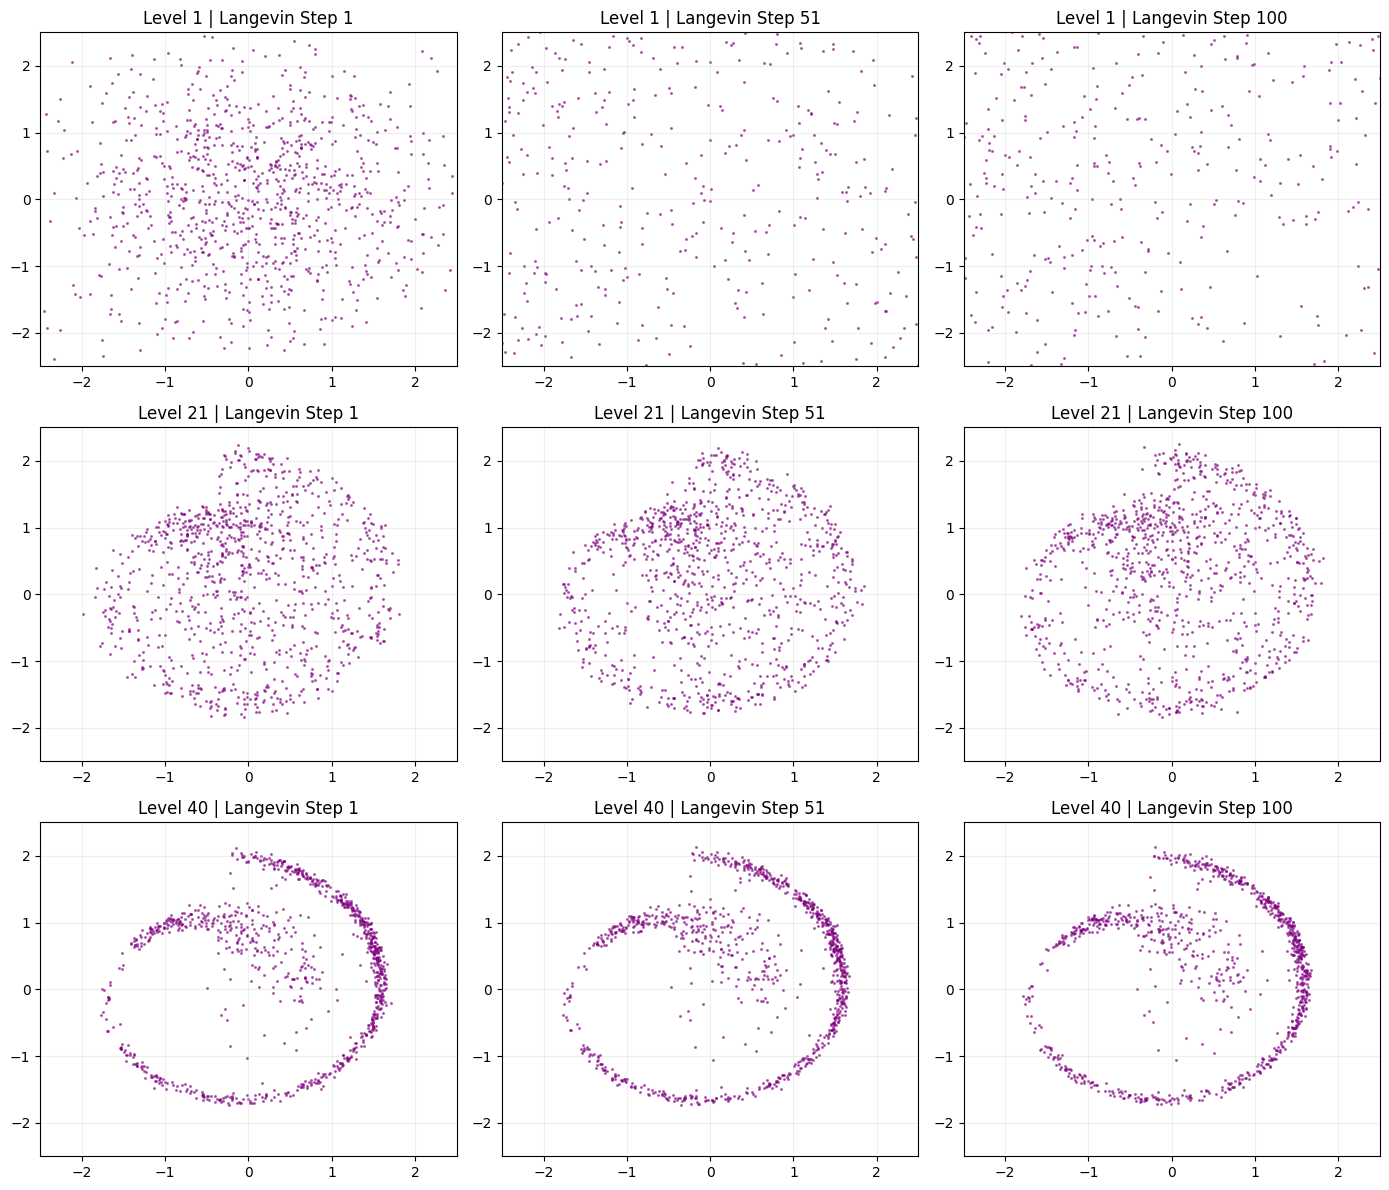

Epoch [400/30000] | Loss: 133.8632
Epoch [800/30000] | Loss: 79.2545
Epoch [1200/30000] | Loss: 114.6438
Epoch [1600/30000] | Loss: 115.9169
Epoch [2000/30000] | Loss: 90.9211
Epoch [2400/30000] | Loss: 153.0769
Epoch [2800/30000] | Loss: 107.0442
Epoch [3200/30000] | Loss: 179.8932
Epoch [3600/30000] | Loss: 122.2600
Epoch [4000/30000] | Loss: 133.8974
Epoch [4400/30000] | Loss: 134.0219
Epoch [4800/30000] | Loss: 133.2677
Epoch [5200/30000] | Loss: 84.3049
Epoch [5600/30000] | Loss: 87.2884
Epoch [6000/30000] | Loss: 176.9347
Epoch [6400/30000] | Loss: 147.4532
Epoch [6800/30000] | Loss: 98.2188
Epoch [7200/30000] | Loss: 161.3167
Epoch [7600/30000] | Loss: 107.7162
Epoch [8000/30000] | Loss: 119.5818
Epoch [8400/30000] | Loss: 132.8529
Epoch [8800/30000] | Loss: 157.7211
Epoch [9200/30000] | Loss: 137.0218
Epoch [9600/30000] | Loss: 117.5962
Epoch [10000/30000] | Loss: 110.8650
Epoch [10400/30000] | Loss: 128.7644
Epoch [10800/30000] | Loss: 138.6567
Epoch [11200/30000] | Loss: 96.0

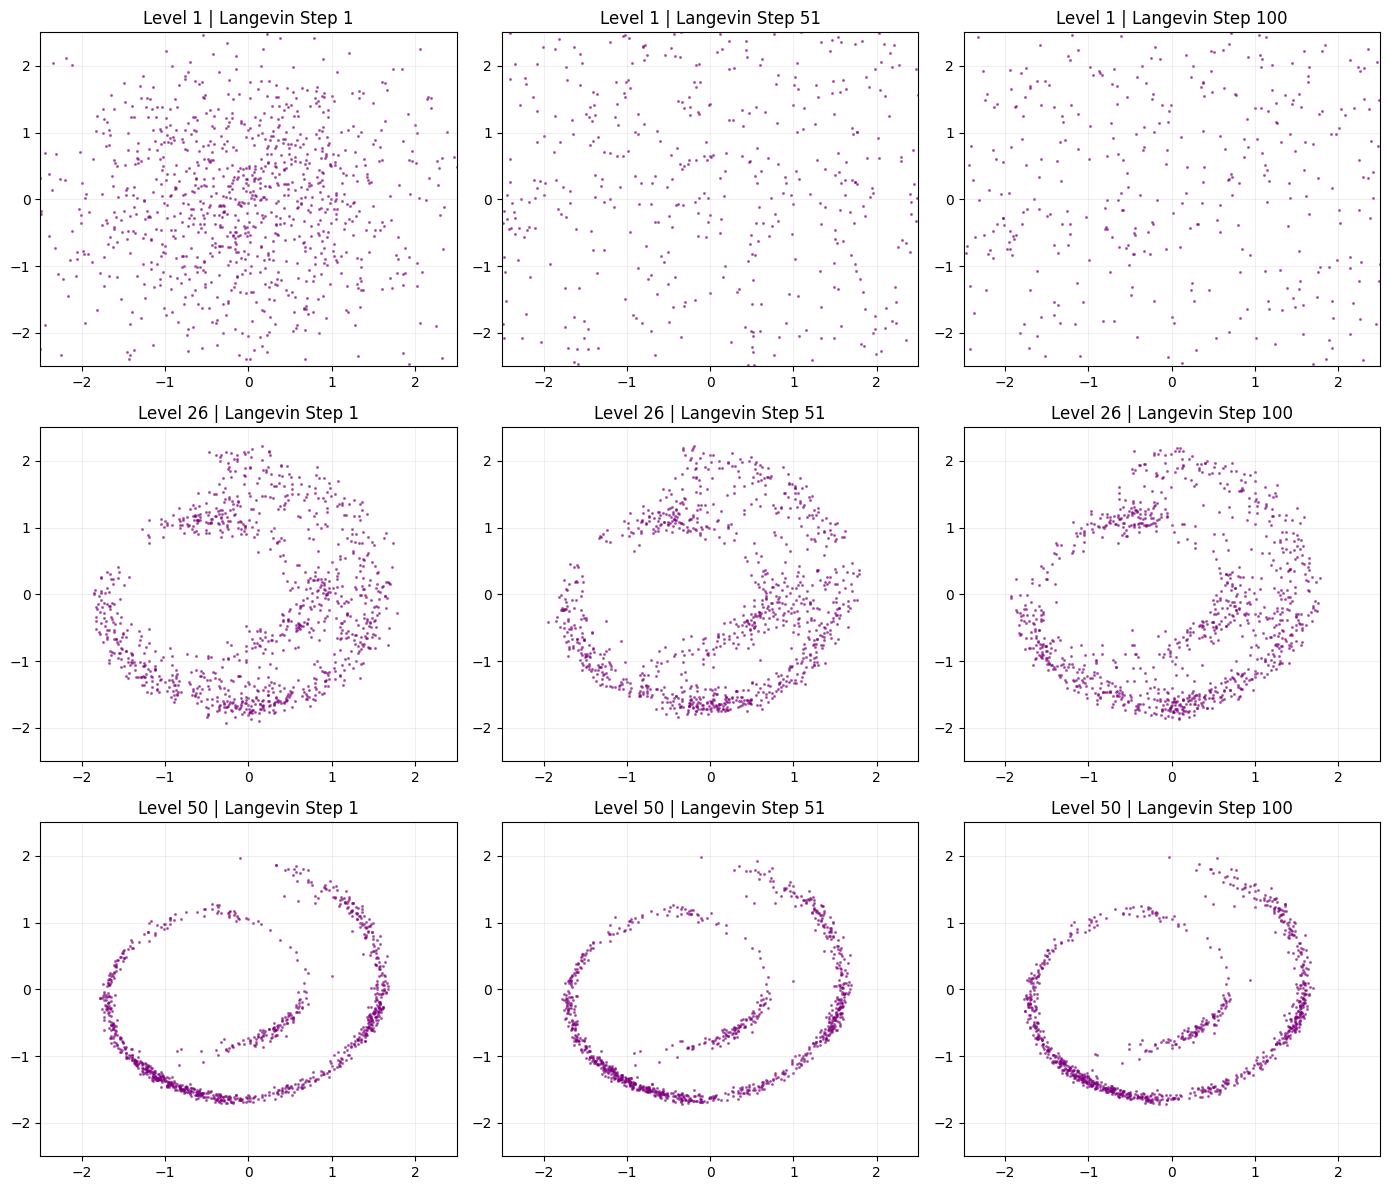

In [604]:
L_SWEEP    = [10, 20, 30, 40, 50]
all_samples_track = {}
fine_history_track = {}
for L in L_SWEEP:
    sched          = make_schedule(SIGMA_1, SIGMA_L, L)
    adjusted_eps = BASELINE_EPS * (10 / L)
    networks[L] = train_network(sched)
    samples, fine_history        = sample_annealed_langevin_fine_tracking(networks[L], sched, 1000, T=100)
    all_samples[L] = samples
    fine_history_track[L] = fine_history

    # final_pts, fine_history = sample_annealed_langevin_fine_tracking(networks[L], sigmas, n_samples=1000, T=100)

    # Create a 3x3 grid (3 distinct noise levels x 3 inner steps each)
    fig, axes = plt.subplots(3, 3, figsize=(14, 12))

    for idx, snapshot in enumerate(fine_history_track[L]):
        row = idx // 3  # Maps to the noise level group
        col = idx % 3   # Maps to inner step t
        
        ax = axes[row, col]
        pts = snapshot['points']
        
        ax.scatter(pts[:, 0], pts[:, 1], s=1.5, alpha=0.5, color="purple")
        ax.set_title(f"Level {snapshot['level']} | Langevin Step {snapshot['inner_step']}")
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

### visualize the evolution per noise level

In [ ]:
## see how it looks for each noise level

def sample_annealed_langevin_with_tracking(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    trajectory = []  # List to store particle positions at each level
    
    with torch.no_grad():
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        # Save initial random state (t=0)
        trajectory.append((0, x.cpu().numpy().copy()))
        
        for i, sigma in enumerate(sigmas):
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            for t in range(T):
                score = network(x, sigma_tensor)
                z = torch.randn_like(x)
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
            
            # Save a snapshot after completing all T steps for this specific noise level
            trajectory.append((i + 1, x.cpu().numpy().copy()))
                
    return x.cpu().numpy(), trajectory

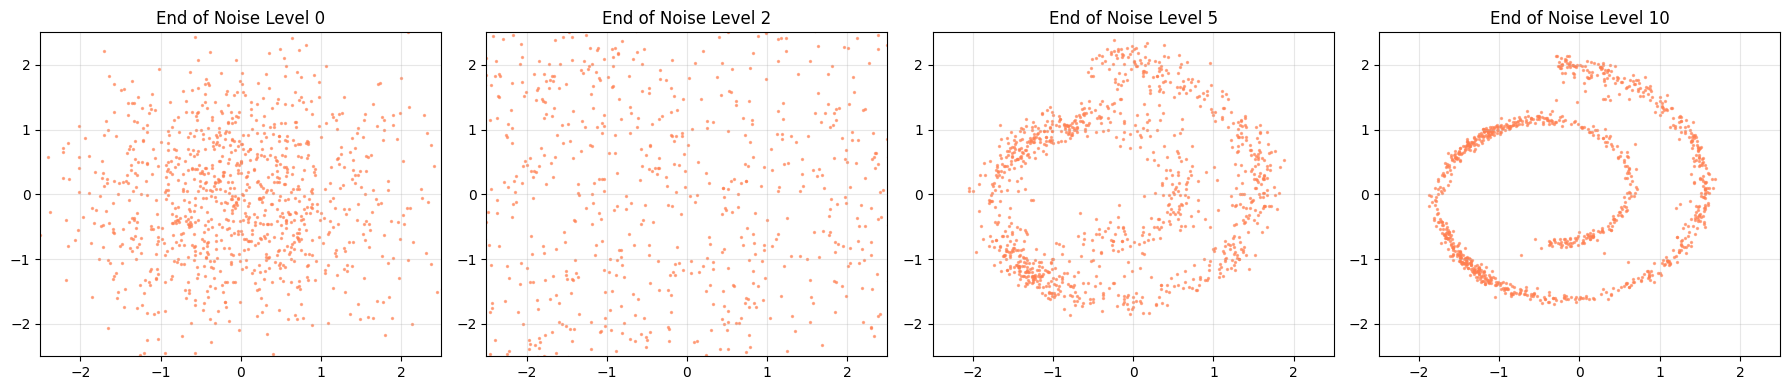

In [ ]:
final_points, history = sample_annealed_langevin_with_tracking(network, sigmas, n_samples=1000, T=50)

# 2. Pick a few snapshots to look at (e.g., initial, quarter-way, half-way, end)
indices_to_plot = [0, len(sigmas)//4, len(sigmas)//2, len(sigmas)]

fig, axes = plt.subplots(1, len(indices_to_plot), figsize=(18, 4))
for idx, step in enumerate(indices_to_plot):
    level_num, points = history[step]
    ax = axes[idx]
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6, color="coral")
    ax.set_title(f"End of Noise Level {level_num}")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### even finer tracking per langevin step

In [670]:
def sample_annealed_langevin_fine_tracking(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    detailed_history = []  # Stores (sigma_index, inner_t, points)
    
    with torch.no_grad():
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        for i, sigma in enumerate(sigmas):
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            for t in range(T):
                score = network(x, sigma_tensor)
                z = torch.randn_like(x)
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
                # Capture the inner dynamics of specific key noise levels
                # (e.g., the first level, a middle level, and the final level)
                if i in [0, len(sigmas)//2, len(sigmas)-1]:
                    # Capture at step 0 (initial snap), middle, and final boiling step
                    if t in [0, T//2, T-1]:
                        detailed_history.append({
                            'level': i + 1,
                            'inner_step': t + 1,
                            'points': x.cpu().numpy().copy()
                        })
                        
    return x.cpu().numpy(), detailed_history

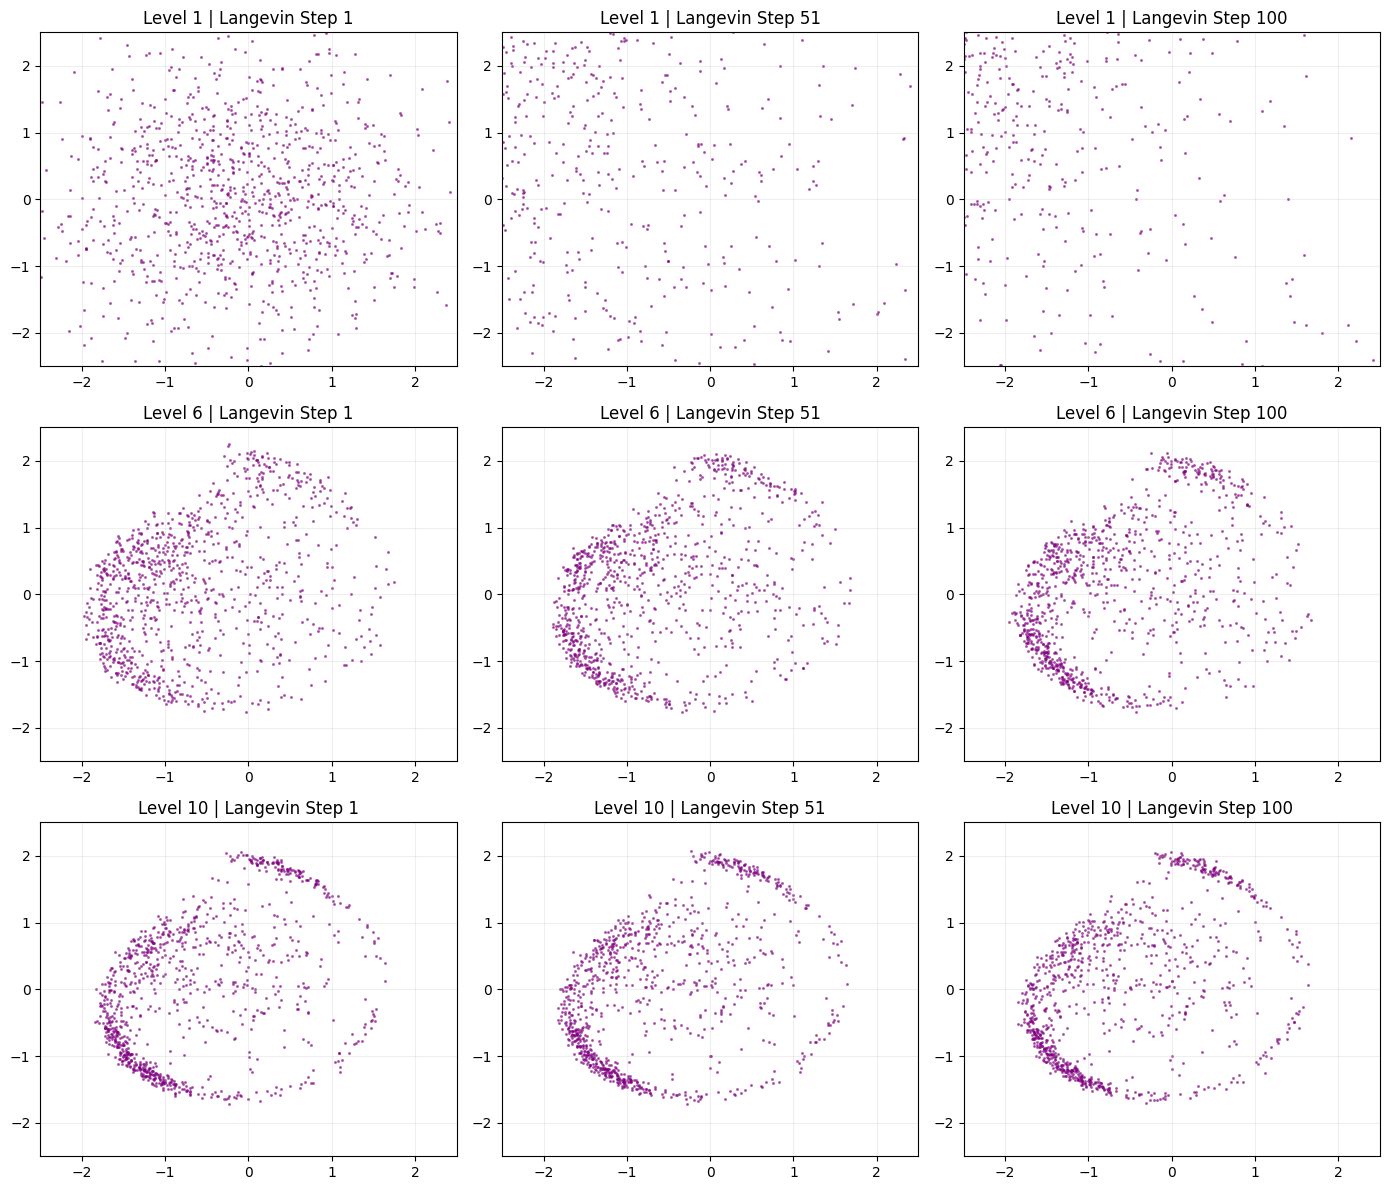

In [ ]:
final_pts, fine_history = sample_annealed_langevin_fine_tracking(network, sigmas, n_samples=1000, T=100)

# Create a 3x3 grid (3 distinct noise levels x 3 inner steps each)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for idx, snapshot in enumerate(fine_history):
    row = idx // 3  # Maps to the noise level group
    col = idx % 3   # Maps to inner step t
    
    ax = axes[row, col]
    pts = snapshot['points']
    
    ax.scatter(pts[:, 0], pts[:, 1], s=1.5, alpha=0.5, color="purple")
    ax.set_title(f"Level {snapshot['level']} | Langevin Step {snapshot['inner_step']}")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()